# Compose multi-panel figures

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.gridspec as gridspec
import string
from PIL import Image

## genome_wide_rates.png

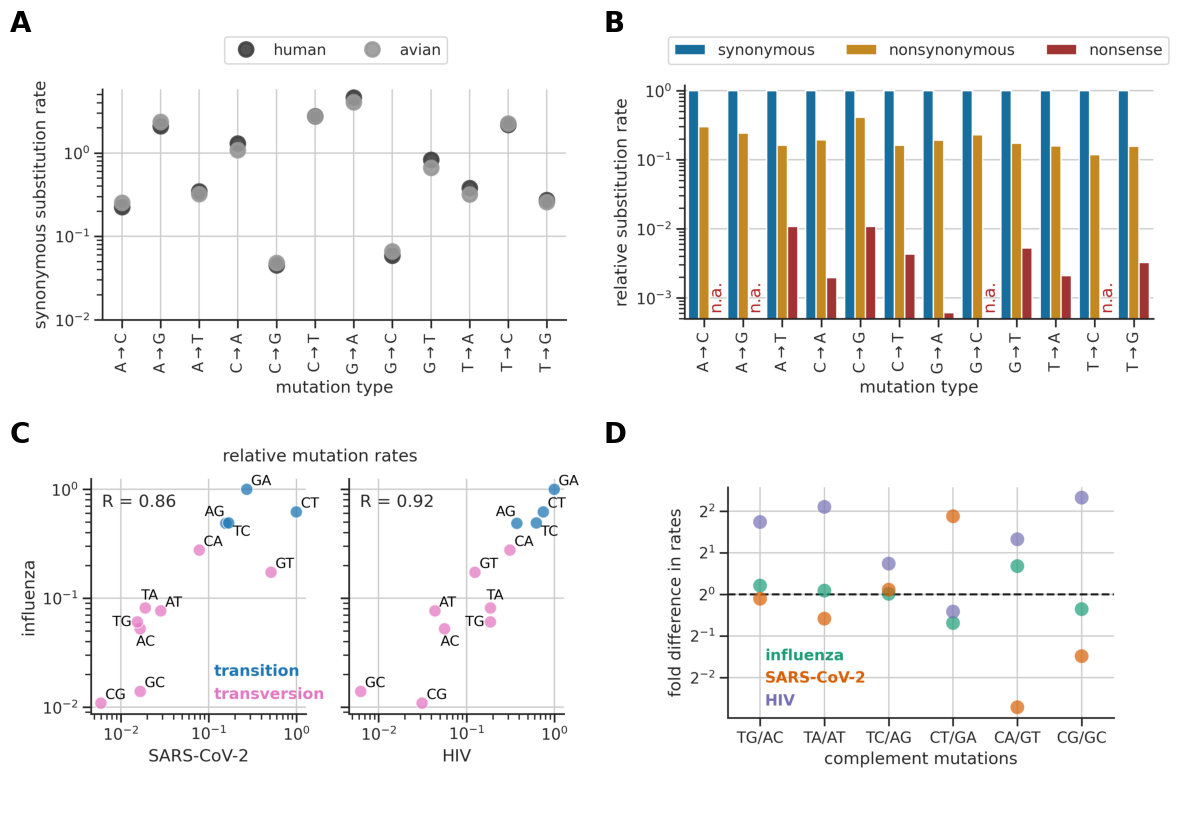

In [2]:
# Paths to the four panel PNGs
panel_paths = [
    "../results/figures/genome_wide_synonymous_rates.png",
    "../results/figures/genome_wide_mut_class_rates.png",
    "../results/figures/genome_wide_rates_comparison.png",
    "../results/figures/genome_wide_fold_differences.png",
]

# Load images
panels = [mpimg.imread(p) for p in panel_paths]

# Panel D's source image is smaller (~1402 px wide) than A/B/C (~1664-1711 px wide),
# so stretching all four into equal-sized axes makes D's text appear larger. Pad D
# with whitespace to match the largest of A/B/C so all panels render at matched scales.
import numpy as np

target_h = max(p.shape[0] for p in panels[:3])
target_w = max(p.shape[1] for p in panels[:3])
img_d = panels[3]
padded_d = np.ones((target_h, target_w, img_d.shape[2]), dtype=img_d.dtype)
y_off = (target_h - img_d.shape[0]) // 2
x_off = (target_w - img_d.shape[1]) // 2
padded_d[y_off:y_off + img_d.shape[0], x_off:x_off + img_d.shape[1]] = img_d
panels[3] = padded_d

# Create 2x2 figure
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, img in zip(axes.flat, panels):
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()

# Force a draw so we can measure each image's rendered extent (= axes bbox once
# tight_layout has matched axes aspect to image aspect).
fig.canvas.draw()

def img_top_fig(ax):
    return ax.images[0].get_window_extent().transformed(fig.transFigure.inverted()).y1

img_tops = [img_top_fig(ax) for ax in axes.flat]  # [A, B, C, D]

# Label placement. Labels use baseline alignment (va="bottom"); text extends upward
# by ~0.7 * fontsize (cap height). Image tops should land at the label midline,
# with row 2 dropped by one label-height for inter-row spacing.
label_fontsize = 20
cap_height_fig = (label_fontsize * 0.7) / 72 / fig.get_figheight()
baseline_gap = 0.005
image_up_shift = baseline_gap + cap_height_fig / 2  # image top at label midline
row2_extra_down = cap_height_fig  # extra gap between rows ≈ one label height

row1_img_top = max(img_tops[0], img_tops[1])
row2_img_top = max(img_tops[2], img_tops[3])

for i, ax in enumerate(axes.flat):
    if i < 2:
        target = row1_img_top + image_up_shift
    else:
        target = row2_img_top + image_up_shift - row2_extra_down
    shift = target - img_tops[i]
    pos = ax.get_position()
    ax.set_position([pos.x0, pos.y0 + shift, pos.width, pos.height])

pos_a = axes[0, 0].get_position()
pos_b = axes[0, 1].get_position()
pos_c = axes[1, 0].get_position()
pos_d = axes[1, 1].get_position()
left_x = min(pos_a.x0, pos_c.x0)
right_x = min(pos_b.x0, pos_d.x0)

label_kwargs = dict(fontsize=label_fontsize, fontweight="bold", va="bottom", ha="left")
fig.text(left_x, row1_img_top + baseline_gap, "A", **label_kwargs)
fig.text(right_x, row1_img_top + baseline_gap, "B", **label_kwargs)
fig.text(left_x, row2_img_top + baseline_gap - row2_extra_down, "C", **label_kwargs)
fig.text(right_x, row2_img_top + baseline_gap - row2_extra_down, "D", **label_kwargs)

composite_path = "../results/figures/genome_wide_composite.png"
plt.savefig(composite_path, dpi=300, bbox_inches="tight")
plt.show()

# matplotlib's bbox accounting treats the axes frame (and source-image internal
# whitespace) as "content", so bbox_inches="tight" leaves dead space at the bottom.
# Trim the saved PNG directly: crop to the non-white bounding box with a small pad.
_trim_arr = np.array(Image.open(composite_path).convert("RGB"))
_nonwhite_rows = np.where(~np.all(_trim_arr >= 250, axis=(1, 2)))[0]
_nonwhite_cols = np.where(~np.all(_trim_arr >= 250, axis=(0, 2)))[0]
if len(_nonwhite_rows) and len(_nonwhite_cols):
    _pad = 15  # ~0.05 in at 300 DPI
    _top = max(0, _nonwhite_rows.min() - _pad)
    _bottom = min(_trim_arr.shape[0], _nonwhite_rows.max() + _pad + 1)
    _left = max(0, _nonwhite_cols.min() - _pad)
    _right = min(_trim_arr.shape[1], _nonwhite_cols.max() + _pad + 1)
    Image.open(composite_path).crop((_left, _top, _right, _bottom)).save(composite_path)

In [3]:
# Resize genome_wide_composite to 6 inches wide, preserving aspect ratio and DPI
dpi = 300
target_width_in = 6
img = Image.open("../results/figures/genome_wide_composite.png")
new_width_px = int(target_width_in * dpi)
scale = new_width_px / img.width
new_height_px = int(img.height * scale)
img_resized = img.resize((new_width_px, new_height_px), Image.LANCZOS)
out_png = "../results/figures/ms_figures/genome_wide_rates.png"
out_pdf = "../results/figures/ms_figures/genome_wide_rates.pdf"
img_resized.save(out_png, dpi=(dpi, dpi))
img_resized.convert("RGB").save(out_pdf, "PDF", resolution=dpi)
print(f"Resized to {new_width_px}x{new_height_px} px ({target_width_in}x{new_height_px/dpi:.1f} in at {dpi} DPI)")

Resized to 1800x1179 px (6x3.9 in at 300 DPI)


## site_specific_rates.png

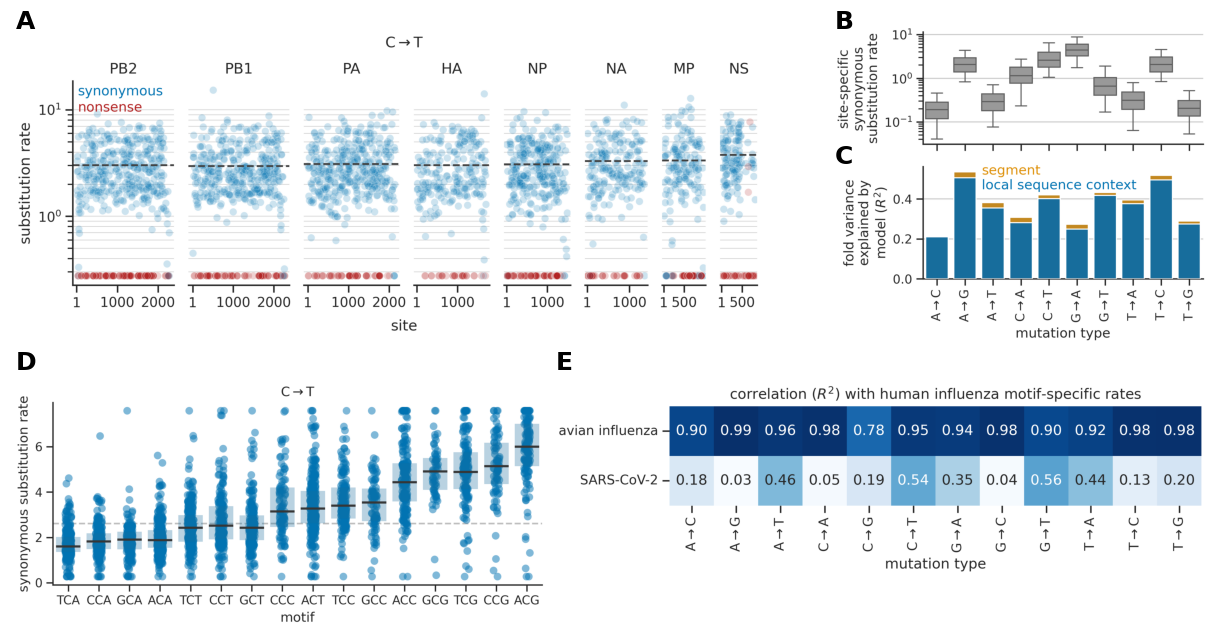

In [4]:
# Load images
img_a = mpimg.imread("../results/figures/mut_rates_C_T.png")
img_bc = mpimg.imread("../results/figures/site_specific_rates_spread.png")
img_d = mpimg.imread("../results/figures/CT_motif_specific_rates.png")
img_e = mpimg.imread("../results/figures/motif_specific_correlations.png")

# Layout: 2 rows x 2 columns with fixed column-width fractions.
# Row 1: B/C is shrunk and right-flushed; A fills the left column (shrunk 5%)
# and is vertically centered with B/C. Row 2: D = 0.45, E = 0.55.
# Images are shifted up so that B/C's top sits just below the B label; the A
# and B labels stay put, but C/D/E labels and D/E images move with the shift.

ar_a = img_a.shape[0] / img_a.shape[1]
ar_bc = img_bc.shape[0] / img_bc.shape[1]
ar_d = img_d.shape[0] / img_d.shape[1]
ar_e = img_e.shape[0] / img_e.shape[1]

# Row 1: B/C shrunk cumulatively, right-flush at x=1.0.
row1_col_gap = 0.02
bc_shrink = 0.81
bc_frac = 0.4 * (1 - row1_col_gap) * bc_shrink
bc_x0 = 1.0 - bc_frac

# Row 1: A occupies the remaining column width, then shrunk by 5%.
a_shrink = 0.95
a_frac = (bc_x0 - row1_col_gap) * a_shrink
a_x0 = 0.0

d_frac, e_frac = 0.45, 0.55

fig_width_in = 12
a_h = a_frac * fig_width_in * ar_a
bc_h = bc_frac * fig_width_in * ar_bc
d_h = d_frac * fig_width_in * ar_d
e_h = e_frac * fig_width_in * ar_e

row1_h_in = max(a_h, bc_h)
row2_h_in = max(d_h, e_h)

top_margin_in = 0.25
row_gap_in = 0.3
bottom_margin_in = 0.05
fig_height_in = top_margin_in + row1_h_in + row_gap_in + row2_h_in + bottom_margin_in

fig = plt.figure(figsize=(fig_width_in, fig_height_in))

row1_top = 1 - top_margin_in / fig_height_in
row1_bot = row1_top - row1_h_in / fig_height_in
row2_top = row1_bot - row_gap_in / fig_height_in

a_h_frac = a_h / fig_height_in
bc_h_frac = bc_h / fig_height_in
d_h_frac = d_h / fig_height_in
e_h_frac = e_h / fig_height_in

label_kwargs = dict(fontsize=18, fontweight="bold", va="bottom", ha="left")
label_pad = 0.005

# Shift all panels (and the C/D/E labels) up so that the B/C image content
# sits just below the B label. The value is tuned empirically to close the
# whitespace visible between the label cap and the plot content (the B/C
# source PNG has ~2% internal padding above its axis frame, and the figure
# top margin adds more whitespace on top of the label).
shift = 0.023

bc_top = row1_top + shift
bc_bot = bc_top - bc_h_frac

# A is vertically centered with B/C (A center == B/C center).
bc_center = bc_bot + bc_h_frac / 2
a_bot = bc_center - a_h_frac / 2

d_top = row2_top + shift
d_bot = d_top - d_h_frac
e_top = row2_top + shift
e_bot = e_top - e_h_frac

ax_a = fig.add_axes([a_x0, a_bot, a_frac, a_h_frac])
ax_a.imshow(img_a)
ax_a.axis("off")

ax_bc = fig.add_axes([bc_x0, bc_bot, bc_frac, bc_h_frac])
ax_bc.imshow(img_bc)
ax_bc.axis("off")

ax_d = fig.add_axes([0.0, d_bot, d_frac, d_h_frac])
ax_d.imshow(img_d)
ax_d.axis("off")

ax_e = fig.add_axes([d_frac, e_bot, e_frac, e_h_frac])
ax_e.imshow(img_e)
ax_e.axis("off")

# A and B labels stay at row1_top + label_pad; C/D/E labels shift up by `shift`.
fig.text(0.005, row1_top + label_pad, "A", **label_kwargs)
fig.text(bc_x0 + 0.005, row1_top + label_pad, "B", **label_kwargs)
fig.text(bc_x0 + 0.005, bc_bot + 0.55 * bc_h_frac, "C", **label_kwargs)
fig.text(0.005, row2_top + label_pad + shift, "D", **label_kwargs)
fig.text(d_frac + 0.005, row2_top + label_pad + shift, "E", **label_kwargs)

plt.savefig(
    "../results/figures/site_specific_rates_composite.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [5]:
# Resize site_specific_rates_composite to 7 inches wide, preserving aspect ratio and DPI
dpi = 300
target_width_in = 7
img = Image.open("../results/figures/site_specific_rates_composite.png")
new_width_px = int(target_width_in * dpi)
scale = new_width_px / img.width
new_height_px = int(img.height * scale)
img_resized = img.resize((new_width_px, new_height_px), Image.LANCZOS)
out_png = "../results/figures/ms_figures/site_specific_rates.png"
out_pdf = "../results/figures/ms_figures/site_specific_rates.pdf"
img_resized.save(out_png, dpi=(dpi, dpi))
img_resized.convert("RGB").save(out_pdf, "PDF", resolution=dpi)
print(f"Resized to {new_width_px}x{new_height_px} px ({target_width_in}x{new_height_px/dpi:.1f} in at {dpi} DPI)")

Resized to 2100x1105 px (7x3.7 in at 300 DPI)


## syn_fitness.png

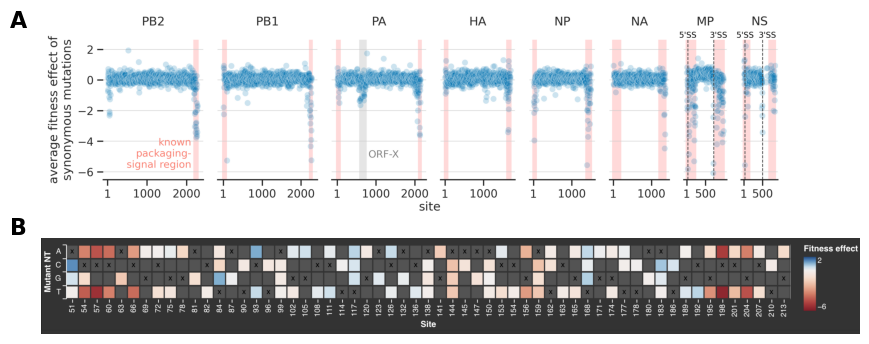

In [6]:
img_a = mpimg.imread("../results/figures/fitness_effect_syn.png")
img_b = mpimg.imread("../results/figures/nt_heatmap.png")

a_aspect = img_a.shape[0] / img_a.shape[1]
b_aspect = img_b.shape[0] / img_b.shape[1]

# Panel A keeps its prior rendered width; B is enlarged by 10%.
a_width_in = 7.44
b_width_in = a_width_in * 1.1

left_margin_in = 0.4
right_margin_in = 0.16
top_margin_in = 0.16
bottom_margin_in = 0.16
row_gap_in = 0.175

a_height_in = a_width_in * a_aspect
b_height_in = b_width_in * b_aspect

fig_width_in = left_margin_in + b_width_in + right_margin_in
fig_height_in = top_margin_in + a_height_in + row_gap_in + b_height_in + bottom_margin_in

fig = plt.figure(figsize=(fig_width_in, fig_height_in))

a_x0 = left_margin_in / fig_width_in
a_y0 = (fig_height_in - top_margin_in - a_height_in) / fig_height_in
a_w = a_width_in / fig_width_in
a_h = a_height_in / fig_height_in
ax_a = fig.add_axes([a_x0, a_y0, a_w, a_h])
ax_a.imshow(img_a)
ax_a.axis("off")

b_x0 = left_margin_in / fig_width_in
b_y0 = bottom_margin_in / fig_height_in
b_w = b_width_in / fig_width_in
b_h = b_height_in / fig_height_in
ax_b = fig.add_axes([b_x0, b_y0, b_w, b_h])
ax_b.imshow(img_b)
ax_b.axis("off")

label_x = 0.01
pos_a = ax_a.get_position()
pos_b = ax_b.get_position()
fig.text(label_x, pos_a.y1, "A",
         fontsize=16, fontweight="bold", va="top", ha="left")
fig.text(label_x, pos_b.y1 - 0.005, "B",
         fontsize=16, fontweight="bold", va="bottom", ha="left")

plt.savefig(
    "../results/figures/syn_fitness.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [7]:
# Resize syn_fitness to 7 inches wide, preserving aspect ratio and DPI
dpi = 300
target_width_in = 7
img = Image.open("../results/figures/syn_fitness.png")
new_width_px = int(target_width_in * dpi)
scale = new_width_px / img.width
new_height_px = int(img.height * scale)
img_resized = img.resize((new_width_px, new_height_px), Image.LANCZOS)
out_png = "../results/figures/ms_figures/syn_fitness.png"
out_pdf = "../results/figures/ms_figures/syn_fitness.pdf"
img_resized.save(out_png, dpi=(dpi, dpi))
img_resized.convert("RGB").save(out_pdf, "PDF", resolution=dpi)
print(f"Resized to {new_width_px}x{new_height_px} px ({target_width_in}x{new_height_px/dpi:.1f} in at {dpi} DPI)")

Resized to 2100x832 px (7x2.8 in at 300 DPI)


## subset_pcp_overlap.png

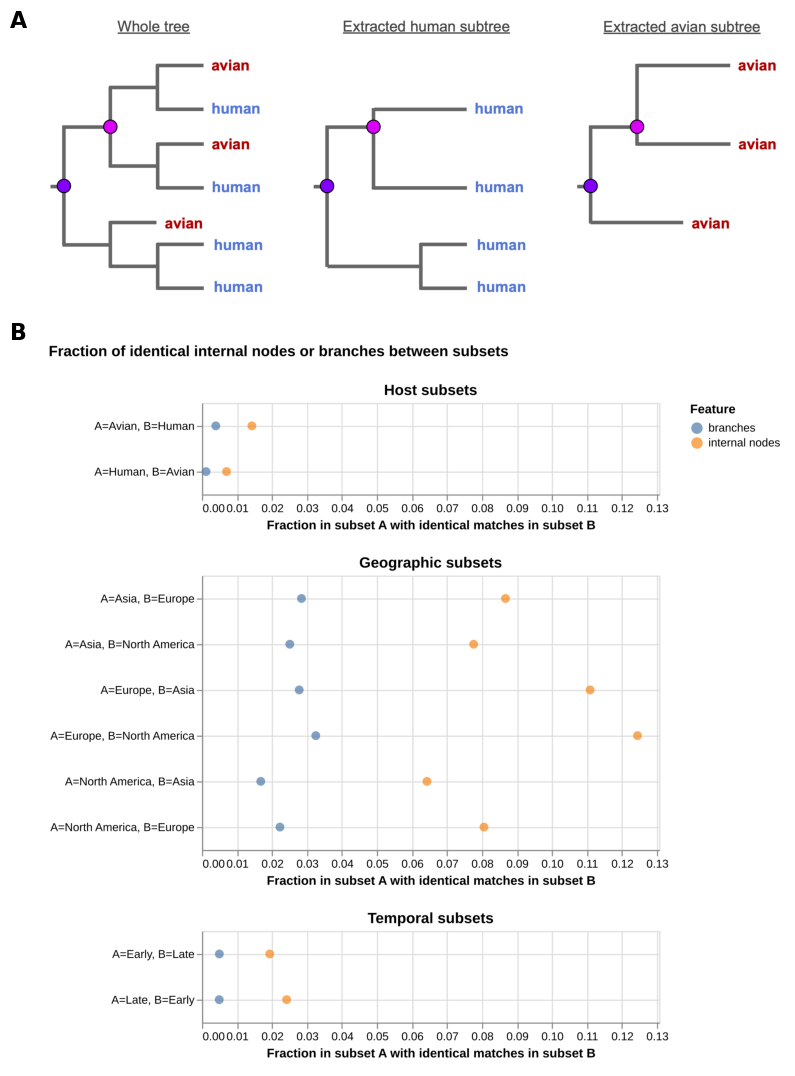

In [8]:
img_a = mpimg.imread("../results/figures/tree_extraction.png")
img_b = mpimg.imread("../results/figures/subset_pcp_overlap_aggregated.png")

# Set panel widths so both panels render at the same width in the figure.
# Height ratio follows from each image's aspect (height/width).
a_aspect = img_a.shape[0] / img_a.shape[1]
b_aspect = img_b.shape[0] / img_b.shape[1]

# Add a modest vertical gap above panel B for its label.
fig_width_in = 8
img_height_in = fig_width_in * (a_aspect + b_aspect)
label_gap_in = 0.175
fig_height_in = img_height_in + label_gap_in
hspace = label_gap_in / (img_height_in / 2)

fig = plt.figure(figsize=(fig_width_in, fig_height_in))
gs = gridspec.GridSpec(
    2, 1,
    height_ratios=[a_aspect, b_aspect],
    hspace=hspace,
    left=0.05,
    right=0.98,
    top=0.98,
    bottom=0.02,
)

ax_a = fig.add_subplot(gs[0])
ax_a.imshow(img_a)
ax_a.axis("off")

ax_b = fig.add_subplot(gs[1])
ax_b.imshow(img_b)
ax_b.axis("off")

label_x = 0.01
pos_a = ax_a.get_position()
pos_b = ax_b.get_position()
fig.text(label_x, pos_a.y1, "A",
         fontsize=16, fontweight="bold", va="top", ha="left")
# Drop the "B" label slightly so it partially overlaps the top of panel B.
fig.text(label_x, pos_b.y1 - 0.005, "B",
         fontsize=16, fontweight="bold", va="bottom", ha="left")

plt.savefig(
    "../results/figures/subset_pcp_overlap_composite.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## subset_fitness_effects.png

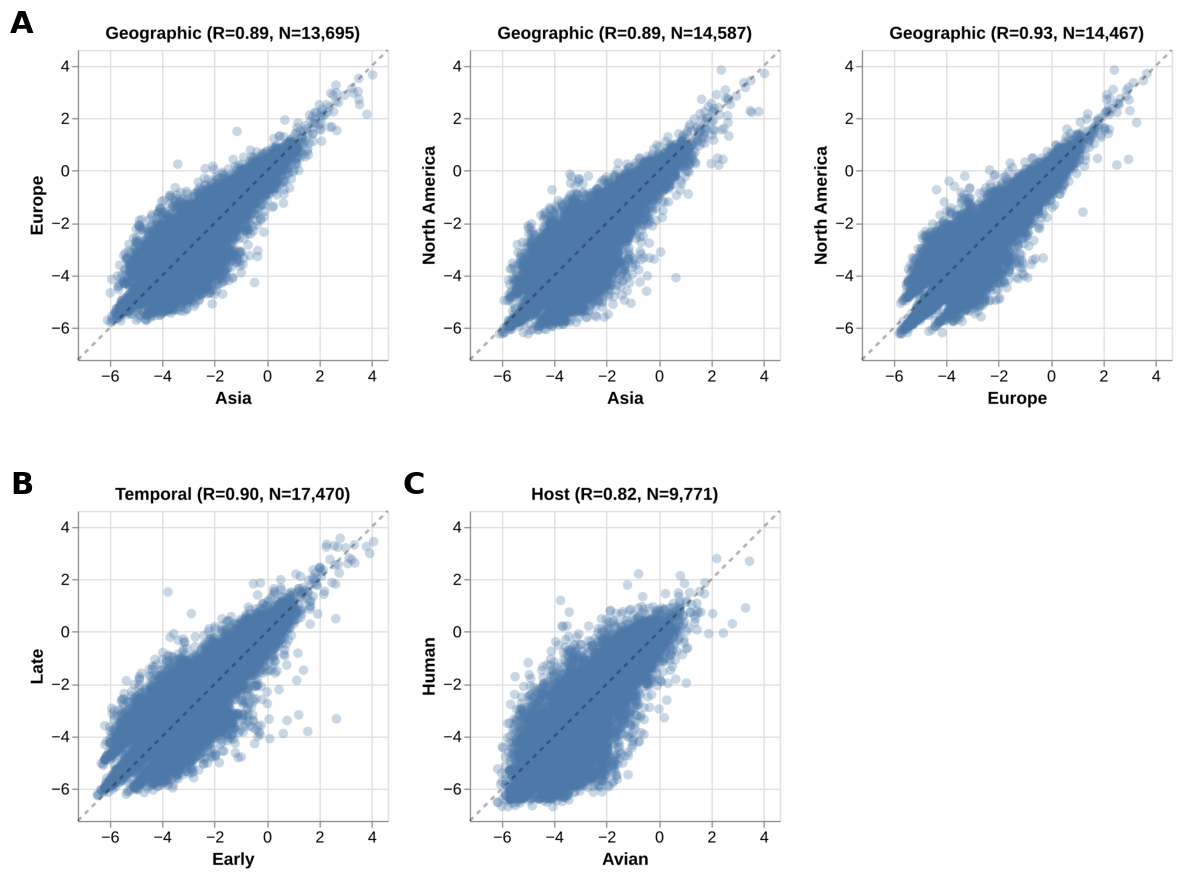

In [9]:
# 3-panel composite of subset fitness-effect scatter plots.
# Panel A (top row): three geographic comparisons.
# Panel B (bottom-left): temporal. Panel C (to the right of B): host.
# Columns are left-justified so the bottom row leaves the right-most
# column empty rather than centering the two plots.

fig_dir = "../results/figures"
geo_paths = [
    f"{fig_dir}/subset_fitness_scatter_geographic_asia_vs_europe.png",
    f"{fig_dir}/subset_fitness_scatter_geographic_asia_vs_north_america.png",
    f"{fig_dir}/subset_fitness_scatter_geographic_europe_vs_north_america.png",
]
temporal_path = f"{fig_dir}/subset_fitness_scatter_temporal_early_vs_late.png"
host_path = f"{fig_dir}/subset_fitness_scatter_host_avian_vs_human.png"

geo_imgs = [mpimg.imread(p) for p in geo_paths]
img_b = mpimg.imread(temporal_path)
img_c = mpimg.imread(host_path)

# All five panels come from the same Altair template, so they share aspect.
aspect = geo_imgs[0].shape[0] / geo_imgs[0].shape[1]

fig = plt.figure(figsize=(12, 12 * aspect * 2 / 3 * 1.1))
gs = gridspec.GridSpec(
    2, 3,
    hspace=0.15,
    wspace=0.05,
    left=0.025,
    right=0.99,
    top=0.95,
    bottom=0.02,
)

# Row 0: three geographic panels (A).
geo_axes = []
for i, img in enumerate(geo_imgs):
    ax = fig.add_subplot(gs[0, i])
    ax.imshow(img)
    ax.axis("off")
    geo_axes.append(ax)

# Row 1: B (temporal) on the left, C (host) next to it; third column empty.
ax_b = fig.add_subplot(gs[1, 0])
ax_b.imshow(img_b)
ax_b.axis("off")

ax_c = fig.add_subplot(gs[1, 1])
ax_c.imshow(img_c)
ax_c.axis("off")

# Panel labels A/B/C centered on each panel's left edge.
label_kwargs = dict(fontsize=22, fontweight="bold", va="top", ha="center")
pos_a = geo_axes[0].get_position()
pos_b = ax_b.get_position()
pos_c = ax_c.get_position()

fig.text(pos_a.x0, pos_a.y1 + 0.01, "A", **label_kwargs)
fig.text(pos_b.x0, pos_b.y1 + 0.01, "B", **label_kwargs)
fig.text(pos_c.x0, pos_c.y1 + 0.01, "C", **label_kwargs)

plt.savefig(
    f"{fig_dir}/subset_fitness_effects_composite.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## ss_heatmaps.png

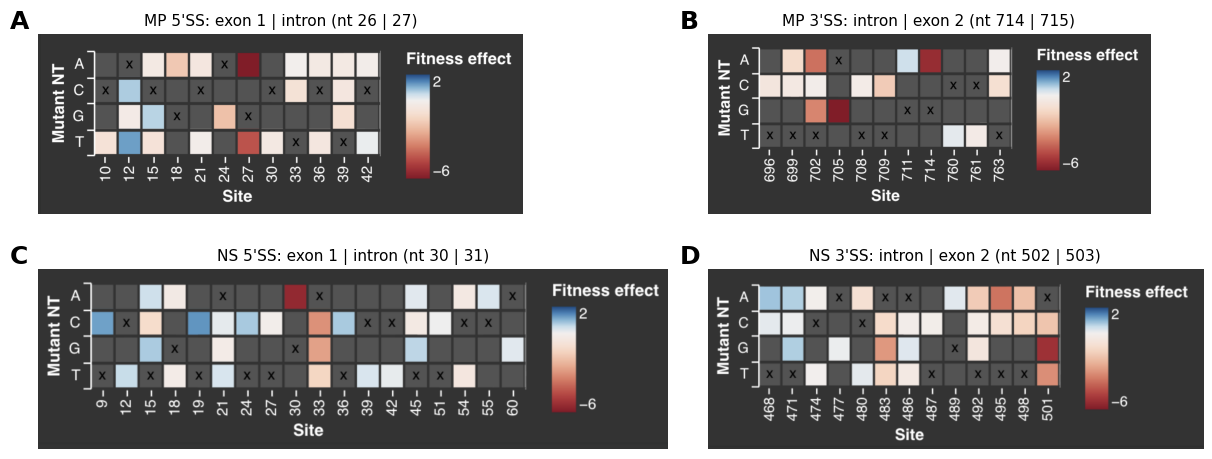

In [10]:
# 2x2 splice-site heatmap composite, panels labeled A-D.
# All four source images are rendered at the same physical height; column
# widths are the max image width in each column, and images are left-flushed
# within their column. This keeps panel labels aligned vertically within
# columns (A/C, B/D) and horizontally within rows (A/B, C/D).
panel_info = [
    [("A", "MP 5'SS: exon 1 | intron (nt 26 | 27)", "../results/figures/MP_5SS.png"),
     ("B", "MP 3'SS: intron | exon 2 (nt 714 | 715)", "../results/figures/MP_3SS.png")],
    [("C", "NS 5'SS: exon 1 | intron (nt 30 | 31)", "../results/figures/NS_5SS.png"),
     ("D", "NS 3'SS: intron | exon 2 (nt 502 | 503)", "../results/figures/NS_3SS.png")],
]

imgs = [[mpimg.imread(p[2]) for p in row] for row in panel_info]
aspects = [[img.shape[0] / img.shape[1] for img in row] for row in imgs]  # h/w

# Shared image height (in inches); widths scale to preserve each image's aspect.
img_h_in = 1.8
widths_in = [[img_h_in / asp for asp in row] for row in aspects]
col_w_in = [max(widths_in[r][c] for r in range(2)) for c in range(2)]

col_gap_in = 0.4
row_gap_in = 0.55
left_pad_in = 0.35   # room for panel labels at the left of each image
top_pad_in = 0.2
right_pad_in = 0.1
bottom_pad_in = 0.1

fig_w_in = left_pad_in + col_w_in[0] + col_gap_in + col_w_in[1] + right_pad_in
fig_h_in = top_pad_in + img_h_in + row_gap_in + img_h_in + bottom_pad_in

fig = plt.figure(figsize=(fig_w_in, fig_h_in))

title_fontsize = 11
label_fontsize = 18
label_offset_in = 0.28  # distance from column's left edge to label's left edge

for row_idx, row in enumerate(panel_info):
    y_top_in = fig_h_in - top_pad_in - row_idx * (img_h_in + row_gap_in)
    y_bot_in = y_top_in - img_h_in
    for col_idx, (label, title, _) in enumerate(row):
        img = imgs[row_idx][col_idx]
        img_w_in = widths_in[row_idx][col_idx]
        col_x0_in = left_pad_in + sum(col_w_in[:col_idx]) + col_idx * col_gap_in

        ax = fig.add_axes([
            col_x0_in / fig_w_in,
            y_bot_in / fig_h_in,
            img_w_in / fig_w_in,
            img_h_in / fig_h_in,
        ])
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(title, fontsize=title_fontsize)

        # Panel label to the left of each image, baseline on the image's top edge.
        fig.text(
            (col_x0_in - label_offset_in) / fig_w_in,
            y_top_in / fig_h_in,
            label,
            fontsize=label_fontsize,
            fontweight="bold",
            va="bottom",
            ha="left",
        )

plt.savefig("../results/figures/ss_heatmaps.png", dpi=300, bbox_inches="tight")
plt.show()